In [7]:
!pip install open_clip_torch timm albumentations scikit-learn matplotlib seaborn tqdm opencv-python-headless scipy transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00


In [8]:
MODEL_NAME = "swin_base"  

MODEL_CONFIGS = {
    "swin_tiny":     {"timm_name": "swin_tiny_patch4_window7_224",    "is_swin": True,  "img_size": 224},
    "swin_small":    {"timm_name": "swin_small_patch4_window7_224",   "is_swin": True,  "img_size": 224},
    "swin_base":     {"timm_name": "swin_base_patch4_window7_224",    "is_swin": True,  "img_size": 224},
    "convnext_tiny": {"timm_name": "convnext_tiny.fb_in22k_ft_in1k",  "is_swin": False, "img_size": 224},
    "convnext_base": {"timm_name": "convnext_base.fb_in22k_ft_in1k",  "is_swin": False, "img_size": 224},
}
assert MODEL_NAME in MODEL_CONFIGS, f"Unknown model: {MODEL_NAME}. Pick from {list(MODEL_CONFIGS.keys())}"
MC = MODEL_CONFIGS[MODEL_NAME]
print(f"\nModel: {MODEL_NAME} ({MC['timm_name']})")
print(f"Is Swin: {MC['is_swin']}, img_size: {MC['img_size']}")


Model: swin_base (swin_base_patch4_window7_224)
Is Swin: True, img_size: 224


In [9]:
from __future__ import annotations
import copy, json, math, os, random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from scipy.stats import f_oneway
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold

import timm

try:
    from open_clip import create_model_from_pretrained, get_tokenizer
    HAS_OPEN_CLIP = True
    print(" open_clip loaded")
except ImportError:
    HAS_OPEN_CLIP = False
    print(" open_clip not found — concept mining disabled")

from transformers import CLIPTokenizer, CLIPTextModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch={torch.__version__}, timm={timm.__version__}, device={DEVICE}")

 open_clip loaded
torch=2.10.0+cu128, timm=1.0.25, device=cuda


In [10]:
NUM_CLASSES   = 8
IMG_SIZE      = MC["img_size"]
BATCH_SIZE    = 32        
EPOCHS        = 48
NUM_WORKERS   = 4

BASE_LR       = 1e-4

BACKBONE_LR   = 3e-5
ETA_MIN       = 1e-6
WEIGHT_DECAY  = 1e-4
GRAD_CLIP     = 1.0
WARMUP_EPOCHS = 3

MIXUP_START   = 5
MIXUP_ALPHA   = 0.2
MIXUP_STOP    = 32       
CUTMIX_ALPHA  = 1.0
CUTMIX_PROB   = 0.5

EMA_DECAY     = 0.9992
FOCAL_GAMMA   = 2.0
SMOOTHING     = 0.10
USE_TTA       = True

N_MINED       = 40
BIOMEDCLIP_ID = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
CLIP_TEXT_DIM = 512      

CACHE_DIR  = "/kaggle/working/cache"
OUTPUT_DIR = "/kaggle/working/outputs"
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"Config: BACKBONE_LR={BACKBONE_LR}, EPOCHS={EPOCHS}, MIXUP_STOP={MIXUP_STOP}")
print(f"Clean epochs after MixUp stop: {EPOCHS - MIXUP_STOP}")

Config: BACKBONE_LR=3e-05, EPOCHS=48, MIXUP_STOP=32
Clean epochs after MixUp stop: 16


In [11]:
# Paths
TRAIN_DIR      = "/kaggle/input/datasets/sujansarkar/isic-2019-multi-modal-classification/Train_Validation_dataset/content/Train_Validation_dataset/train"
VAL_DIR        = "/kaggle/input/datasets/sujansarkar/isic-2019-multi-modal-classification/Train_Validation_dataset/content/Train_Validation_dataset/val"
TEST_DIR       = "/kaggle/input/datasets/sujansarkar/isic-2019-multi-modal-classification/Test_dataset/content/test_dataset2"
TRAIN_META_CSV = "/kaggle/input/datasets/sujansarkar/isic-2019-multi-modal-classification/ISIC_2019_Training_Metadata.csv"
TEST_META_CSV  = "/kaggle/input/datasets/sujansarkar/isic-2019-multi-modal-classification/ISIC_2019_Test_Metadata.csv"

In [12]:
LABEL_MAP   = {"AK":0,"BCC":1,"BKL":2,"DF":3,"MEL":4,"NV":5,"SCC":6,"VASC":7}
LABEL_NAMES = ["AK","BCC","BKL","DF","MEL","NV","SCC","VASC"]

CANDIDATE_CONCEPTS = [
    # Pigment network
    "dermoscopy image with thin reticular pigment network",
    "dermoscopy image with thick reticular pigment network",
    "dermoscopy image with atypical meshwork pigment pattern",
    "dermoscopy image with annular pigment network",
    "dermoscopy image with broken fragmented pigment network",
    "dermoscopy image with regular pigment network",
    "dermoscopy image with absence of pigment network",
    # Dots/globules
    "dermoscopy image with regular brown globules",
    "dermoscopy image with irregular globules",
    "dermoscopy image with milky red globules",
    "dermoscopy image with peripheral rim of brown globules",
    "dermoscopy image with clods or large globules",
    # Colors
    "dermoscopy image with multiple colors",
    "dermoscopy image with uniform tan brown color",
    "dermoscopy image with black color areas",
    "dermoscopy image with blue color areas",
    "dermoscopy image with white color areas",
    "dermoscopy image with red color areas",
    "dermoscopy image with pink color areas",
    "dermoscopy image with dark brown black pigmentation",
    "dermoscopy image with hypopigmented areas",
    # Borders/symmetry
    "dermoscopy image with irregular border",
    "dermoscopy image with regular smooth border",
    "dermoscopy image with asymmetric lesion",
    "dermoscopy image with symmetric lesion",
    "dermoscopy image with border notching",
    "dermoscopy image with well-circumscribed border",
    "dermoscopy image with radial streaming at periphery",
    # MEL-specific
    "dermoscopy image with blue white veil",
    "dermoscopy image with regression white scar like areas",
    "dermoscopy image with regression blue peppering",
    "dermoscopy image with atypical vascular pattern",
    "dermoscopy image with pseudopods or streaks",
    "dermoscopy image with shiny white lines",
    "dermoscopy image with melanoma specific structures",
    "dermoscopy image with spreading pigmentation beyond border",
    # BCC-specific
    "dermoscopy image with arborizing vessels",
    "dermoscopy image with branched telangiectasias",
    "dermoscopy image with leaf-like structures",
    "dermoscopy image with spoke wheel structures",
    "dermoscopy image with ovoid gray-blue nests",
    "dermoscopy image with ulceration",
    "dermoscopy image with basal cell carcinoma pattern",
    # AK/SCC keratotic
    "dermoscopy image with surface scales",
    "dermoscopy image with keratinous plugs",
    "dermoscopy image with white circles or rings",
    "dermoscopy image with strawberry pattern",
    "dermoscopy image with looped or hairpin vessels",
    "dermoscopy image with surface keratosis",
    "dermoscopy image with brown dots in follicular openings",
    "dermoscopy image with actinic keratosis vessels",
    # BKL/SK
    "dermoscopy image with comedo-like openings",
    "dermoscopy image with milia-like cysts",
    "dermoscopy image with cerebriform pattern",
    "dermoscopy image with gyri and sulci pattern",
    "dermoscopy image with fissures and ridges",
    "dermoscopy image with fingerprinting pattern",
    "dermoscopy image with moth-eaten border seborrheic",
    "dermoscopy image with light brown fat fingers",
    "dermoscopy image with stuck on appearance",
    # Vascular
    "dermoscopy image with dotted vessels",
    "dermoscopy image with comma vessels",
    "dermoscopy image with linear irregular vessels",
    "dermoscopy image with polymorphous vessels",
    "dermoscopy image with lacunes red lagoons",
    "dermoscopy image with red-blue lacunae vascular lesion",
    "dermoscopy image with angioma-like pattern",
    # DF-specific
    "dermoscopy image with central white scar",
    "dermoscopy image with peripheral pigment network",
    "dermoscopy image with central white patch",
    "dermoscopy image with pseudonetwork with white center",
    # NV-specific
    "dermoscopy image of benign melanocytic nevus",
    "dermoscopy image with starburst pattern",
    "dermoscopy image with cobblestone pattern",
    "dermoscopy image with homogeneous pattern",
    "dermoscopy image with reticular pattern nevus",
    "dermoscopy image with globular pattern nevus",
    # Surface/general
    "dermoscopy image with shiny smooth surface",
    "dermoscopy image with rough scaly surface",
    "dermoscopy image with crusting on surface",
    "dermoscopy image with dark lesion overall",
    "dermoscopy image with light colored lesion",
    # Class anchors (8)
    "dermoscopy image of actinic keratosis skin lesion",
    "dermoscopy image of basal cell carcinoma skin lesion",
    "dermoscopy image of benign keratosis skin lesion",
    "dermoscopy image of dermatofibroma skin lesion",
    "dermoscopy image of melanoma skin lesion",
    "dermoscopy image of benign melanocytic nevus skin lesion",
    "dermoscopy image of squamous cell carcinoma skin lesion",
    "dermoscopy image of vascular lesion skin",
    # ABCDE / clinical risk
    "dermoscopy image with high risk features for melanoma",
    "dermoscopy image with low risk benign features",
    "dermoscopy image with early melanoma features",
    "dermoscopy image with multicomponent pattern",
    "dermoscopy showing amelanotic melanoma",
    "dermoscopy showing dysplastic lesion",
    "dermoscopy showing solar lentigo",
    "dermoscopy showing seborrheic keratosis",
    "dermoscopy image pigmented lesion",
    "dermoscopy image non-pigmented lesion",
]
print(f"Candidate concepts: {len(CANDIDATE_CONCEPTS)}")

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(42)

Candidate concepts: 100


In [13]:
def create_df(folder):
    rows = []
    for cls in sorted(os.listdir(folder)):
        d = os.path.join(folder, cls)
        if not os.path.isdir(d) or cls not in LABEL_MAP: continue
        for img in sorted(os.listdir(d)):
            p = os.path.abspath(os.path.join(d, img))
            if os.path.isfile(p):
                rows.append({"image": os.path.join(cls, img),
                              "image_id": Path(img).stem,
                              "image_path": p,
                              "label": LABEL_MAP[cls]})
    return pd.DataFrame(rows)

def normalize_field(v, default):
    if v is None or pd.isna(v): return default
    s = str(v).strip().lower()
    return s if s else default

def build_clinical_description(row):
    age  = row.get('age_approx', None)
    sex  = row.get('sex', None)
    site = row.get('anatom_site_general', None)
    a = f"{int(age)}-year-old" if age is not None and not pd.isna(age) else "unknown age"
    s = normalize_field(sex, "patient") if normalize_field(sex,"x") in {'male','female'} else "patient"
    si = normalize_field(site, "an unspecified location")
    return f"A {a} {s} with a skin lesion on the {si}."

def load_meta_df(csv_path):
    if not csv_path or not os.path.exists(csv_path):
        return pd.DataFrame(columns=["image","age_approx","sex","anatom_site_general"])
    df = pd.read_csv(csv_path)
    if "anatom_site_general_challenge" in df.columns and "anatom_site_general" not in df.columns:
        df = df.rename(columns={"anatom_site_general_challenge": "anatom_site_general"})
    return df

def get_sampler(df):
    c = df['label'].value_counts().sort_index().values.astype(np.float64)
    w = np.array([1.0/c[l] for l in df['label'].values], dtype=np.float64)
    return WeightedRandomSampler(w, len(w), replacement=True)

print("Loading splits...")
train_df = create_df(TRAIN_DIR).sample(frac=1, random_state=42).reset_index(drop=True)
val_df   = create_df(VAL_DIR)
test_df  = create_df(TEST_DIR)
print(f"Train:{len(train_df)}  Val:{len(val_df)}  Test:{len(test_df)}")
print(train_df['label'].value_counts().sort_index())

Loading splits...
Train:20262  Val:5069  Test:6191
label
0      693
1     2658
2     2099
3      191
4     3617
5    10300
6      502
7      202
Name: count, dtype: int64


In [ ]:
from tqdm import tqdm

CLIP_TEXT_CACHE = os.path.join(CACHE_DIR, "clip_text_meta.pt")

@torch.no_grad()
def build_clip_meta_dict(csv_path, tokenizer, text_model, device, batch_size=64):
    df = pd.read_csv(csv_path) if isinstance(csv_path, str) else csv_path
    if 'image' not in df.columns: return {}

    image_ids = df['image'].tolist()

    print("Building descriptions...")
    descs = df.apply(build_clinical_description, axis=1).tolist()

    text_model.eval()
    all_embs = []

    print("Encoding with CLIP...")
    for i in tqdm(range(0, len(descs), batch_size)):
        inp = tokenizer(
            descs[i:i+batch_size],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        ).to(device)

        out = text_model(**inp).pooler_output
        out = F.normalize(out, dim=-1).cpu()

        all_embs.append(out)

    embs = torch.cat(all_embs, dim=0)
    return {iid: embs[j] for j, iid in enumerate(image_ids)}

def get_clip_emb(img_path_or_id, meta_dict):
    key = os.path.splitext(os.path.basename(img_path_or_id))[0]
    return meta_dict.get(key, meta_dict.get(img_path_or_id, torch.zeros(CLIP_TEXT_DIM)))

if os.path.exists(CLIP_TEXT_CACHE):
    print("Loading cached CLIP text embeddings...")
    clip_cache = torch.load(CLIP_TEXT_CACHE, weights_only=False)
    train_meta = clip_cache['train']
    test_meta  = clip_cache['test']
else:
    print("Computing CLIP text embeddings...")
    print(f"Using device: {DEVICE}")

    tok = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
    clm = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)

    for p in clm.parameters():
        p.requires_grad = False

    train_meta = build_clip_meta_dict(TRAIN_META_CSV, tok, clm, DEVICE)
    print(f"  Train metadata: {len(train_meta)} entries")

    try:
        test_meta = build_clip_meta_dict(TEST_META_CSV, tok, clm, DEVICE)
        print(f"  Test metadata:  {len(test_meta)} entries")
    except Exception:
        test_meta = {}
        print("  No test metadata")

    clm.cpu()
    del clm, tok
    torch.cuda.empty_cache()

    torch.save({'train': train_meta, 'test': test_meta}, CLIP_TEXT_CACHE)
    print("  CLIP text cache saved.")

print(" CLIP text embeddings ready")

In [ ]:
CONCEPT_CACHE = os.path.join(CACHE_DIR, "mined_concepts.pt")
ALL_SCORES_CACHE = os.path.join(CACHE_DIR, "concept_scores_all.pt")

class _ImgDs(Dataset):
    """For fast parallel BiomedCLIP encoding."""
    def __init__(self, paths, preprocess):
        self.paths = paths; self.pp = preprocess
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        with Image.open(self.paths[i]) as img:
            return self.pp(img.convert("RGB"))

@torch.no_grad()
def encode_imgs_parallel(paths, model, pp, batch=128, workers=4):
    ds  = _ImgDs(paths, pp)
    kw  = {"num_workers":workers, "pin_memory":True, "persistent_workers":True, "prefetch_factor":2} if workers>0 else {}
    ld  = DataLoader(ds, batch_size=batch, shuffle=False, **kw)
    out = []
    for b in tqdm(ld, desc="BiomedCLIP encoding"):
        out.append(F.normalize(model.encode_image(b.to(DEVICE)), dim=-1).cpu())
    return torch.cat(out, dim=0)

@torch.no_grad()
def encode_texts_bmc(texts, model, tok, batch=256):
    out = []
    for i in range(0, len(texts), batch):
        t = tok(texts[i:i+batch], context_length=256).to(DEVICE)
        out.append(F.normalize(model.encode_text(t), dim=-1).cpu())
    return torch.cat(out, dim=0)

def mine_concepts(train_embs, train_labels, model, tok, top_k, cache):
    if os.path.exists(cache):
        print(f"Loading cached mined concepts: {cache}")
        d = torch.load(cache, weights_only=False)
        return d['prompts'], d['embeds']
    print(f"Mining top-{top_k} concepts via ANOVA F-stat...")
    cand_embs = encode_texts_bmc(CANDIDATE_CONCEPTS, model, tok)
    sim = train_embs.float() @ cand_embs.float().T  # (N_train, n_cands)
    f_stats = np.zeros(len(CANDIDATE_CONCEPTS))
    for j in range(len(CANDIDATE_CONCEPTS)):
        scores = sim[:, j].numpy()
        groups = [scores[train_labels==c] for c in range(8) if (train_labels==c).sum()>1]
        if len(groups) >= 2:
            try: f_stats[j] = float(f_oneway(*groups)[0]) or 0.0
            except: pass
    top_idx = np.argsort(f_stats)[::-1][:top_k].copy()
    prompts = [CANDIDATE_CONCEPTS[i] for i in top_idx]
    embeds  = cand_embs[top_idx]
    print(f"Top-{top_k} mined concepts:")
    for r,(i,p) in enumerate(zip(top_idx,prompts),1):
        print(f"  {r:2d}. F={f_stats[i]:.1f}  '{p}'")
    torch.save({'prompts':prompts,'embeds':embeds}, cache)
    return prompts, embeds

if os.path.exists(ALL_SCORES_CACHE):
    print("Loading cached concept scores...")
    scores_cache = torch.load(ALL_SCORES_CACHE, weights_only=False)
    concept_scores_by_id = scores_cache['scores']
    mined_prompts        = scores_cache['prompts']
    CONCEPT_DIM          = len(mined_prompts)
    print(f" Concept scores loaded. concept_dim={CONCEPT_DIM}")
else:
    if not HAS_OPEN_CLIP:
        print("WARNING: open_clip not available, using zero concept scores")
        all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
        concept_scores_by_id = {row['image_id']: torch.zeros(N_MINED) for _,row in all_df.iterrows()}
        mined_prompts = CANDIDATE_CONCEPTS[:N_MINED]
        CONCEPT_DIM = N_MINED
    else:
        print("Loading BiomedCLIP...")
        bmc_model, bmc_pp = create_model_from_pretrained(BIOMEDCLIP_ID)
        bmc_tok            = get_tokenizer(BIOMEDCLIP_ID)
        bmc_model          = bmc_model.to(DEVICE).eval()
        for p in bmc_model.parameters(): p.requires_grad = False
        print(" BiomedCLIP loaded")

        all_df   = pd.concat([train_df, val_df, test_df], ignore_index=True)
        all_paths= all_df['image_path'].tolist()
        all_ids  = all_df['image_id'].tolist()
        print(f"Encoding {len(all_paths)} images...")
        all_embs = encode_imgs_parallel(all_paths, bmc_model, bmc_pp)

        train_mask = all_df['image_path'].isin(set(train_df['image_path'].tolist())).values
        train_embs = all_embs[train_mask]
        train_labs = all_df['label'].values[train_mask]

        mined_prompts, mined_embeds = mine_concepts(
            train_embs, train_labs, bmc_model, bmc_tok, N_MINED, CONCEPT_CACHE
        )

        all_scores = all_embs.float() @ mined_embeds.float().T  # (N_all, 40)
        concept_scores_by_id = {iid: all_scores[i] for i, iid in enumerate(all_ids)}

        CONCEPT_DIM = len(mined_prompts)
        torch.save({'scores': concept_scores_by_id, 'prompts': mined_prompts}, ALL_SCORES_CACHE)
        print(f" Concept scores saved. concept_dim={CONCEPT_DIM}")

        bmc_model.cpu(); del bmc_model; torch.cuda.empty_cache()

ZERO_CONCEPT = torch.zeros(CONCEPT_DIM)
ZERO_TEXT    = torch.zeros(CLIP_TEXT_DIM)
print(f"concept_dim={CONCEPT_DIM}, clip_text_dim={CLIP_TEXT_DIM}")

In [25]:


_norm = A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
_t2   = ToTensorV2()
train_tfms = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE,IMG_SIZE), scale=(0.60,1.0), ratio=(0.85,1.15), p=1.0),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.90,1.10), rotate=(-25,25), p=0.7),
    A.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.05, p=0.5),
    A.RandomGamma(gamma_limit=(80,120), p=0.3),
    A.OneOf([A.GaussNoise(p=1.0), A.MotionBlur(blur_limit=5,p=1.0), A.GaussianBlur(blur_limit=(3,5),p=1.0)], p=0.3),
    A.OneOf([A.CLAHE(p=1.0), A.RandomBrightnessContrast(p=1.0), A.HueSaturationValue(p=1.0)], p=0.4),
    A.CoarseDropout(num_holes_range=(4,8), hole_height_range=(8,16), hole_width_range=(8,16), p=0.3),
    _norm, _t2,
])
val_tfms = A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), _norm, _t2])
tta_tfms = [
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), _norm, _t2]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.HorizontalFlip(p=1.0), _norm, _t2]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.VerticalFlip(p=1.0),   _norm, _t2]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.RandomRotate90(p=1.0), _norm, _t2]),
    A.Compose([A.Resize(IMG_SIZE,IMG_SIZE), A.Transpose(p=1.0),      _norm, _t2]),  # contiguous in infer
]

In [26]:
class SkinDataset(Dataset):
    def __init__(self, df, img_dir_or_none, transform, meta_dict, concept_dict):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir_or_none
        self.transform = transform
        self.meta = meta_dict
        self.concepts = concept_dict

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if 'image_path' in row and os.path.exists(row['image_path']):
            p = row['image_path']
        else:
            p = os.path.join(self.img_dir, row['image'])

        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']

        iid = row.get('image_id', os.path.splitext(os.path.basename(p))[0])
        img_key = row.get('image', os.path.join(row.get('label_name',''), os.path.basename(p))) \
                  if 'image' in row else iid

        clip_emb = get_clip_emb(img_key, self.meta)
        concept  = self.concepts.get(iid, ZERO_CONCEPT).clone()

        return img, clip_emb, concept, torch.tensor(int(row['label']), dtype=torch.long)

In [14]:
class TextGuidedCrossAttention(nn.Module):
    def __init__(self, vdim, tdim=512, heads=8):
        super().__init__()
        self.tp   = nn.Linear(tdim, vdim)
        self.nv   = nn.LayerNorm(vdim)
        self.nt   = nn.LayerNorm(vdim)
        self.attn = nn.MultiheadAttention(vdim, heads, dropout=0.1, batch_first=True)
        self.op   = nn.Linear(vdim, vdim)
        self.drop = nn.Dropout(0.1)
        self.null = nn.Parameter(torch.zeros(1, tdim)) 

    def forward(self, v, t):
        is_missing = (t.abs().sum(-1, keepdim=True) < 1e-6).float()
        null = self.null.expand(v.size(0), -1)
        t = (1.0 - is_missing) * t + is_missing * null
        kv = self.nt(self.tp(t)).unsqueeze(1)
        q  = self.nv(v).unsqueeze(1)
        a,_ = self.attn(q, kv, kv)
        return v + self.drop(self.op(a.squeeze(1)))


class ConceptGate(nn.Module):
    """Gated fusion of visual features with mined concept scores."""
    def __init__(self, vdim, cdim):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(cdim, vdim), nn.LayerNorm(vdim), nn.GELU())
        self.gate = nn.Sequential(nn.Linear(vdim*2, vdim), nn.GELU(), nn.Linear(vdim, vdim), nn.Sigmoid())
        self.norm = nn.LayerNorm(vdim)

    def forward(self, v, c):
        cp = self.proj(c)
        alpha = self.gate(torch.cat([v, cp], dim=1))
        return self.norm(v + alpha * cp)


class ISICModel(nn.Module):
    def __init__(self, model_name: str, concept_dim: int, clip_text_dim: int = 512):
        super().__init__()
        mc = MODEL_CONFIGS[model_name]

       
        self.backbone = timm.create_model(mc['timm_name'], pretrained=True, features_only=True)
        self.is_swin  = mc['is_swin']
        self.pool     = nn.AdaptiveAvgPool2d(1)
        feat_dim      = self.backbone.feature_info.channels()[-1]
        print(f"  Backbone: {mc['timm_name']} → feat_dim={feat_dim}")

        self.text_ca = TextGuidedCrossAttention(feat_dim, clip_text_dim, heads=8)

        self.concept_gate = ConceptGate(feat_dim, concept_dim)

        self.head = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(feat_dim, 512), nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, NUM_CLASSES),
        )

        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Trainable params: {n/1e6:.1f}M")

    def _extract(self, x):
        feats = self.backbone(x)[-1]
        if self.is_swin and feats.ndim == 4 and feats.shape[1] < 64:
            feats = feats.permute(0, 3, 1, 2).contiguous()
        return self.pool(feats).flatten(1)

    def forward(self, x, clip_emb, concept):
        v = self._extract(x)            
        v = self.text_ca(v, clip_emb)   
        v = self.concept_gate(v, concept)
        return self.head(v)



print(f"Building {MODEL_NAME}...")
_m = ISICModel(MODEL_NAME, CONCEPT_DIM, CLIP_TEXT_DIM).to(DEVICE)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_c = torch.zeros(2, CLIP_TEXT_DIM).to(DEVICE)
_k = torch.zeros(2, CONCEPT_DIM).to(DEVICE)
with torch.no_grad(): _o = _m(_x, _c, _k)
print(f"  Output shape: {_o.shape}")
del _m, _x, _c, _k; torch.cuda.empty_cache()

Building swin_base...


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

  Backbone: swin_base_patch4_window7_224 → feat_dim=1024
  Trainable params: 96.2M
  Output shape: torch.Size([2, 8])


In [34]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.10, num_classes=NUM_CLASSES):
        super().__init__()
        self.gamma=gamma; self.sm=smoothing; self.nc=num_classes

    def forward(self, logits, targets):
        with torch.no_grad():
            s = torch.full_like(logits, self.sm/max(self.nc-1,1))
            s.scatter_(1, targets.unsqueeze(1), 1.0-self.sm)
        lp = F.log_softmax(logits, 1)
        ce = -(s*lp).sum(1)
        return ((1-torch.exp(-ce))**self.gamma * ce).mean()

def mix_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred,ya)+(1-lam)*crit(pred,yb)

def mix_batch(x, ce, co, y, mx=0.2, cm=1.0, cp=0.5):
    idx = torch.randperm(x.size(0), device=x.device)
    if np.random.rand() < cp:
        lam = np.random.beta(cm,cm)
        _,_,h,w = x.shape
        r=math.sqrt(1-lam); cw,ch=int(w*r),int(h*r)
        cx,cy=np.random.randint(w),np.random.randint(h)
        x1,y1=max(0,cx-cw//2),max(0,cy-ch//2)
        x2,y2=min(w,cx+cw//2),min(h,cy+ch//2)
        x[:,:,y1:y2,x1:x2]=x[idx,:,y1:y2,x1:x2]
        lam=1-(x2-x1)*(y2-y1)/(w*h)
    else:
        lam=np.random.beta(mx,mx); x=lam*x+(1-lam)*x[idx]
    return x,lam*ce+(1-lam)*ce[idx],lam*co+(1-lam)*co[idx],y,y[idx],float(lam)

class EMA:
    def __init__(self, model, decay=0.999):
        self.m=model; self.d=decay
        self.shadow={n:p.data.clone() for n,p in model.named_parameters() if p.requires_grad}
        self.backup={}
    def update(self):
        for n,p in self.m.named_parameters():
            if p.requires_grad: self.shadow[n]=self.d*self.shadow[n]+(1-self.d)*p.data
    def apply(self):
        for n,p in self.m.named_parameters():
            if p.requires_grad: self.backup[n]=p.data.clone(); p.data=self.shadow[n]
    def restore(self):
        for n,p in self.m.named_parameters():
            if p.requires_grad: p.data=self.backup[n]
        self.backup={}

In [35]:
def build_optimizer(model):
    bp, hp = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        if n.startswith('backbone.'): bp.append(p)
        else: hp.append(p)
    print(f"Backbone params: {sum(p.numel() for p in bp)/1e6:.1f}M @ lr={BACKBONE_LR:.1e}")
    print(f"Head params:     {sum(p.numel() for p in hp)/1e6:.1f}M @ lr={BASE_LR:.1e}")
    return torch.optim.AdamW([
        {'params': bp, 'lr': BACKBONE_LR, 'weight_decay': WEIGHT_DECAY},
        {'params': hp, 'lr': BASE_LR,     'weight_decay': WEIGHT_DECAY},
    ])

def build_scheduler(opt, steps_per_epoch):
    total = EPOCHS * steps_per_epoch
    warm  = WARMUP_EPOCHS * steps_per_epoch
    def fn(step):
        if step < warm: return (step+1)/max(1,warm)
        p = (step-warm)/max(1,total-warm)
        fl = ETA_MIN/BASE_LR
        return fl + (1-fl)*0.5*(1+math.cos(math.pi*p))
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=fn)

def build_loaders(tr_df, va_df, tr_meta, va_meta):
    kw = {'num_workers': NUM_WORKERS, 'pin_memory': True}
    if NUM_WORKERS > 0: kw.update({'persistent_workers':True, 'prefetch_factor':2})
    tr_ds = SkinDataset(tr_df, TRAIN_DIR, train_tfms, tr_meta, concept_scores_by_id)
    va_ds = SkinDataset(va_df, VAL_DIR,   val_tfms,   va_meta, concept_scores_by_id)
    return (
        DataLoader(tr_ds, BATCH_SIZE, sampler=get_sampler(tr_df), **kw),
        DataLoader(va_ds, BATCH_SIZE, shuffle=False, **kw),
    )

In [36]:
def train_epoch(model, loader, opt, sched, scaler, crit, ema, epoch):
    model.train(); total=0.0; P=[]; L=[]
    for x, ce, co, y in tqdm(loader, desc=f"Training ep{epoch+1}: ", leave=False):
        x  = x.to(DEVICE, non_blocking=True)
        ce = ce.to(DEVICE, non_blocking=True)
        co = co.to(DEVICE, non_blocking=True)
        y  = y.to(DEVICE, non_blocking=True)

        do_mix = (MIXUP_START <= epoch < MIXUP_STOP) and np.random.rand() < 0.85
        if do_mix:
            x, ce, co, ya, yb, lam = mix_batch(x, ce, co, y, MIXUP_ALPHA, CUTMIX_ALPHA, CUTMIX_PROB)
        else:
            ya, yb, lam = y, y, 1.0

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE=='cuda')):
            logits = model(x, ce, co)
            loss   = mix_criterion(crit, logits, ya, yb, lam) if do_mix else crit(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update(); sched.step(); ema.update()

        total += loss.item()
        P.extend(logits.argmax(1).detach().cpu().numpy())
        L.extend(y.detach().cpu().numpy())
    return total/max(len(loader),1), accuracy_score(L,P), f1_score(L,P,average='macro'), balanced_accuracy_score(L,P)


@torch.no_grad()
def eval_df(model, df, img_dir, meta_dict, use_tta=True, desc="Eval"):
    """Evaluate on a DataFrame using item-by-item TTA (matches previous notebooks)."""
    model.eval()
    PA=[]; LA=[]
    tfms = tta_tfms if use_tta else [val_tfms]

    for row in tqdm(df.itertuples(index=False), total=len(df), desc=desc, leave=False):
        # Load image
        if hasattr(row,'image_path') and os.path.exists(row.image_path):
            img = cv2.imread(row.image_path)
        else:
            img = cv2.imread(os.path.join(img_dir, row.image))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        iid = row.image_id if hasattr(row,'image_id') else os.path.splitext(os.path.basename(row.image))[0]
        img_key = row.image if hasattr(row,'image') else iid

        clip_emb = get_clip_emb(img_key, meta_dict).unsqueeze(0).to(DEVICE)
        concept  = concept_scores_by_id.get(iid, ZERO_CONCEPT).unsqueeze(0).to(DEVICE)

        views = [t(image=img)['image'].unsqueeze(0).to(DEVICE) for t in tfms]
        stacked = torch.cat(views, dim=0)  # (n_views, 3, H, W)
        clip_exp = clip_emb.expand(len(views), -1)
        conc_exp = concept.expand(len(views), -1)

        with torch.amp.autocast("cuda", enabled=(DEVICE=='cuda')):
            logits = model(stacked, clip_exp, conc_exp)
        probs = F.softmax(logits, dim=1).mean(0)

        PA.append(probs.cpu().numpy()); LA.append(int(row.label))

    PA = np.array(PA); LA = np.array(LA); pred = PA.argmax(1)
    return accuracy_score(LA,pred), f1_score(LA,pred,average='macro'), \
           recall_score(LA,pred,average='macro'), balanced_accuracy_score(LA,pred), pred, LA, PA

In [ ]:
CKPT_PATH = os.path.join(OUTPUT_DIR, f"best_{MODEL_NAME}.pth")

def train_and_save(model_name):
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"Checkpoint: {CKPT_PATH}")
    print(f"{'='*60}")

    train_loader, val_loader = build_loaders(train_df, val_df, train_meta, train_meta)
    model  = ISICModel(model_name, CONCEPT_DIM, CLIP_TEXT_DIM).to(DEVICE)
    opt    = build_optimizer(model)
    sched  = build_scheduler(opt, len(train_loader))
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE=='cuda'))
    crit   = FocalLoss(FOCAL_GAMMA, SMOOTHING)
    ema    = EMA(model, EMA_DECAY)

    best_f1 = 0.0; history = []

    for epoch in range(EPOCHS):
        tr_loss, tr_acc, tr_f1, tr_bal = train_epoch(model, train_loader, opt, sched, scaler, crit, ema, epoch)

        ema.apply()
        try:
            va_acc, va_f1, va_rec, va_bal, preds, labels, _ = eval_df(model, val_df, VAL_DIR, train_meta, use_tta=True, desc="Val")
        finally:
            ema.restore()

        tag = "(mix)" if MIXUP_START<=epoch<MIXUP_STOP else "(clean)"
        print(f"\n[{model_name}] Epoch {epoch+1}/{EPOCHS} {tag}  backbone_lr={opt.param_groups[0]['lr']:.1e}")
        print(f"  Train Acc:{tr_acc:.4f} F1:{tr_f1:.4f} BalAcc:{tr_bal:.4f} Loss:{tr_loss:.4f}")
        print(f"  Val   Acc:{va_acc:.4f} F1:{va_f1:.4f} Rec:{va_rec:.4f} BalAcc:{va_bal:.4f}")

        cf1 = f1_score(labels, preds, average=None)
        print("  Per-class: " + " ".join(f"{n}:{s:.3f}" for n,s in zip(LABEL_NAMES, cf1)))

        if (epoch+1) % 5 == 0:
            print(classification_report(labels, preds, target_names=LABEL_NAMES))
            cm = confusion_matrix(labels, preds)
            plt.figure(figsize=(9,7))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
            plt.title(f"{model_name} - Epoch {epoch+1}"); plt.tight_layout(); plt.show()

        if va_f1 > best_f1:
            best_f1 = va_f1
            print(f"   ★ New Best F1: {va_f1:.4f}  (BalAcc:{va_bal:.4f})")
            torch.save({
                'model_state': copy.deepcopy(model.state_dict()),
                'best_val_f1': best_f1, 'epoch': epoch+1,
                'model_name': model_name,
                'concept_dim': CONCEPT_DIM, 'clip_text_dim': CLIP_TEXT_DIM,
            }, CKPT_PATH)

        history.append({'epoch':epoch+1,'tr_f1':tr_f1,'va_f1':va_f1,'tr_bal':tr_bal,'va_bal':va_bal})

    pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, f"history_{model_name}.csv"), index=False)
    print(f"\n[{model_name}] Done. Best val F1 = {best_f1:.4f}")
    print(f"Checkpoint saved: {CKPT_PATH}")
    return best_f1

best = train_and_save(MODEL_NAME)

In [ ]:
def load_model(ckpt_path):
    ck    = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    mn    = ck['model_name']
    model = ISICModel(mn, ck['concept_dim'], ck['clip_text_dim']).to(DEVICE)
    model.load_state_dict(ck['model_state'])
    print(f"Loaded {mn}  (val F1={ck['best_val_f1']:.4f}, ep{ck['epoch']})")
    return model, mn

model, mn = load_model(CKPT_PATH)
te_acc, te_f1, te_rec, te_bal, te_preds, te_labels, _ = eval_df(
    model, test_df, TEST_DIR, test_meta, use_tta=True, desc="Test"
)

print(f"\n[{mn}] TEST  Acc:{te_acc:.4f}  F1:{te_f1:.4f}  BalAcc:{te_bal:.4f}")
print(classification_report(te_labels, te_preds, target_names=LABEL_NAMES))

plt.figure(figsize=(9,7))
sns.heatmap(confusion_matrix(te_labels, te_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title(f"{mn} - Test Set"); plt.tight_layout(); plt.show()

In [16]:
convnext_path = "/kaggle/input/models/asikmallick/asik/pytorch/default/1"
swin_path = "/kaggle/input/models/asikmallick/best-swin-base-isic/pytorch/default/1"
OUTPUT_DIRS = [convnext_path, swin_path]
CACHE_DIR = "/kaggle/input/datasets/asikmallick/isic-precomputed-cache/isic_2019_precomputed_cache"

In [17]:
import os, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                             f1_score, classification_report, confusion_matrix)
import torch.nn.functional as F
            

REQUIRED_CACHES = ["clip_text_meta.pt", "concept_scores_all.pt", "mined_concepts.pt"]
for f in REQUIRED_CACHES:
    path = os.path.join(CACHE_DIR, f)
    assert os.path.exists(path), f" Missing cache: {path}"
    print(f"Found cache: {f}")

print("Loading cached embeddings...")
clip_cache = torch.load(os.path.join(CACHE_DIR, "clip_text_meta.pt"), weights_only=False, map_location='cpu')
train_meta = clip_cache['train']
test_meta  = clip_cache.get('test', {})

scores_cache = torch.load(os.path.join(CACHE_DIR, "concept_scores_all.pt"), weights_only=False, map_location='cpu')
concept_scores_by_id = scores_cache['scores']
mined_prompts = scores_cache['prompts']
CONCEPT_DIM = len(mined_prompts)
CLIP_TEXT_DIM = 512

ZERO_CONCEPT = torch.zeros(CONCEPT_DIM)
ZERO_TEXT    = torch.zeros(CLIP_TEXT_DIM)
print(f" Caches loaded: concept_dim={CONCEPT_DIM}, clip_text_dim={CLIP_TEXT_DIM}")

Found cache: clip_text_meta.pt
Found cache: concept_scores_all.pt
Found cache: mined_concepts.pt
Loading cached embeddings...
 Caches loaded: concept_dim=40, clip_text_dim=512


In [18]:
def find_checkpoints(output_dirs):
    """Search multiple directories for best_*.pth files"""
    ckpts = []
    for out_dir in output_dirs:
        if not os.path.exists(out_dir):
            print(f" Directory not found: {out_dir}")
            continue
        for f in os.listdir(out_dir):
            if f.startswith('best_') and f.endswith('.pth'):
                ckpts.append((os.path.join(out_dir, f), f))
    return ckpts

ckpt_entries = find_checkpoints(OUTPUT_DIRS)
print(f"Found {len(ckpt_entries)} checkpoint(s):")
for full_path, fname in ckpt_entries:
    ck = torch.load(full_path, map_location='cpu', weights_only=False)
    print(f"  {fname} → {ck['model_name']} | val_f1={ck['best_val_f1']:.4f} | ep{ck['epoch']} | path: {full_path}")

if len(ckpt_entries) < 2:
    print("\n Need ≥2 checkpoints to ensemble. Train the second model first.")
else:
    print(f"\n Ensembling {len(ckpt_entries)} models: mean of softmax probabilities")

Found 2 checkpoint(s):
  best_convnext_base-89f1.pth → convnext_base | val_f1=0.8890 | ep39 | path: /kaggle/input/models/asikmallick/asik/pytorch/default/1/best_convnext_base-89f1.pth
  best_swin_base_89f1.pth → swin_base | val_f1=0.8908 | ep32 | path: /kaggle/input/models/asikmallick/best-swin-base-isic/pytorch/default/1/best_swin_base_89f1.pth

 Ensembling 2 models: mean of softmax probabilities


In [19]:
import os, torch, torch.nn.functional as F
import cv2, numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

if 'DEVICE' not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def get_clip_emb(img_path_or_id, meta_dict):
    """Extracts image_id key and returns cached CLIP embedding."""
    key = os.path.splitext(os.path.basename(img_path_or_id))[0]
    return meta_dict.get(key, meta_dict.get(img_path_or_id, torch.zeros(CLIP_TEXT_DIM)))

_norm = A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
_t2   = ToTensorV2()
val_tfms = A.Compose([A.Resize(224,224), _norm, _t2])
tta_tfms = [
    A.Compose([A.Resize(224,224), _norm, _t2]),
    A.Compose([A.Resize(224,224), A.HorizontalFlip(p=1.0), _norm, _t2]),
    A.Compose([A.Resize(224,224), A.VerticalFlip(p=1.0),   _norm, _t2]),
    A.Compose([A.Resize(224,224), A.RandomRotate90(p=1.0), _norm, _t2]),
    A.Compose([A.Resize(224,224), A.Transpose(p=1.0),      _norm, _t2]),
]

@torch.no_grad()
def eval_df(model, df, img_dir, meta_dict, use_tta=True, desc="Eval"):
    model.eval()
    PA, LA = [], []
    tfms = tta_tfms if use_tta else [val_tfms]
    
    for row in tqdm(df.itertuples(index=False), total=len(df), desc=desc, leave=False):
        if hasattr(row, 'image_path') and os.path.exists(row.image_path):
            img = cv2.imread(row.image_path)
        else:
            img = cv2.imread(os.path.join(img_dir, row.image))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        iid = row.image_id if hasattr(row, 'image_id') else os.path.splitext(os.path.basename(row.image))[0]
        img_key = row.image if hasattr(row, 'image') else iid
        
        clip_emb = get_clip_emb(img_key, meta_dict).unsqueeze(0).to(DEVICE)
        concept  = concept_scores_by_id.get(iid, ZERO_CONCEPT).unsqueeze(0).to(DEVICE)
      
        views = [t(image=img)['image'].unsqueeze(0).to(DEVICE) for t in tfms]
        stacked = torch.cat(views, dim=0)
        clip_exp = clip_emb.expand(len(views), -1)
        conc_exp = concept.expand(len(views), -1)
        
        with torch.amp.autocast("cuda", enabled=(DEVICE=='cuda')):
            logits = model(stacked, clip_exp, conc_exp)
            probs = F.softmax(logits, dim=1).mean(0)
            
        PA.append(probs.cpu().numpy())
        LA.append(int(row.label))
        
    PA = np.array(PA)
    LA = np.array(LA)
    pred = PA.argmax(1)
    return None, None, None, None, pred, LA, PA

 Found cache: clip_text_meta.pt
 Found cache: concept_scores_all.pt
 Found cache: mined_concepts.pt
Loading cached embeddings...
 Caches loaded: concept_dim=40, clip_text_dim=512
   Found: best_convnext_base-89f1.pth in /kaggle/input/models/asikmallick/asik/pytorch/default/1
   Found: best_swin_base_89f1.pth in /kaggle/input/models/asikmallick/best-swin-base-isic/pytorch/default/1

Found 2 checkpoint(s) for ensembling:
  best_convnext_base-89f1.pth → convnext_base | val_f1=0.8890 | ep39
  best_swin_base_89f1.pth → swin_base | val_f1=0.8908 | ep32

 Ensembling 2 models: mean of softmax probabilities
  Backbone: convnext_base.fb_in22k_ft_in1k → feat_dim=1024
  Trainable params: 97.1M

→ Evaluating convnext_base on validation...


→ Evaluating convnext_base on test...


  Backbone: swin_base_patch4_window7_224 → feat_dim=1024
  Trainable params: 96.2M

→ Evaluating swin_base on validation...


→ Evaluating swin_base on test...



ENSEMBLE RESULTS

 VALIDATION  Acc:0.9185  F1(macro):0.9015  BalAcc:0.8924
              precision    recall  f1-score   support

          AK       0.90      0.83      0.86       174
         BCC       0.92      0.97      0.94       665
         BKL       0.87      0.89      0.88       525
          DF       0.95      0.88      0.91        48
         MEL       0.88      0.84      0.86       905
          NV       0.94      0.95      0.95      2575
         SCC       0.89      0.83      0.86       126
        VASC       0.94      0.96      0.95        51

    accuracy                           0.92      5069
   macro avg       0.91      0.89      0.90      5069
weighted avg       0.92      0.92      0.92      5069


 TEST       Acc:0.7616  F1(macro):0.6581  BalAcc:0.6119
              precision    recall  f1-score   support

          AK       0.54      0.39      0.45       374
         BCC       0.71      0.87      0.78       975
         BKL       0.57      0.52      0.54       660

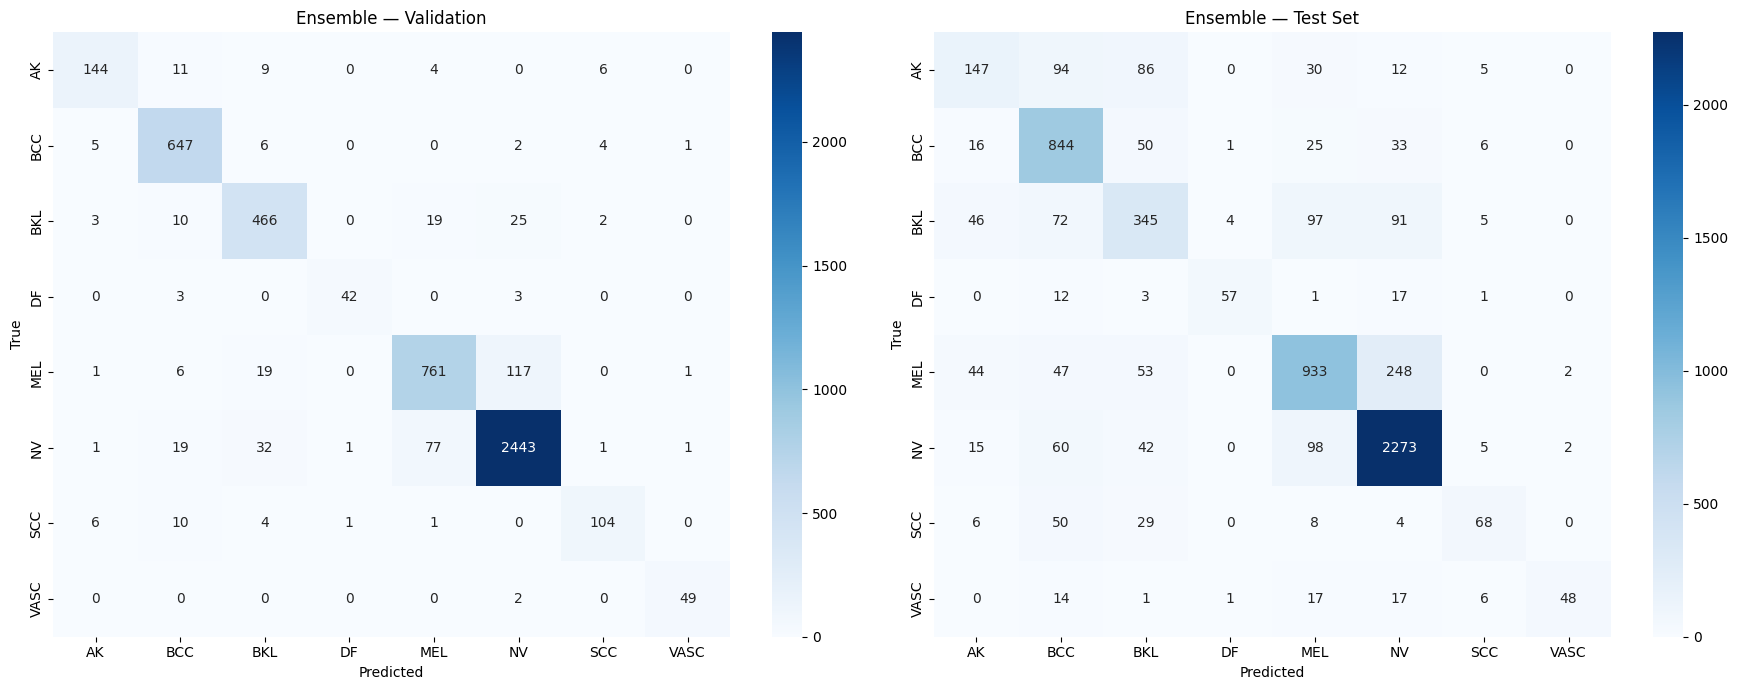


 All ensemble outputs saved to /kaggle/working/


In [21]:
import os, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, 
                             f1_score, classification_report, confusion_matrix)
import torch.nn.functional as F

REQUIRED_CACHES = ["clip_text_meta.pt", "concept_scores_all.pt", "mined_concepts.pt"]
for f in REQUIRED_CACHES:
    path = os.path.join(CACHE_DIR, f)
    assert os.path.exists(path), f" Missing cache: {path}"
    print(f" Found cache: {f}")

print("Loading cached embeddings...")
clip_cache = torch.load(os.path.join(CACHE_DIR, "clip_text_meta.pt"), weights_only=False, map_location='cpu')
train_meta = clip_cache['train']
test_meta  = clip_cache.get('test', {})

scores_cache = torch.load(os.path.join(CACHE_DIR, "concept_scores_all.pt"), weights_only=False, map_location='cpu')
concept_scores_by_id = scores_cache['scores']
mined_prompts = scores_cache['prompts']
CONCEPT_DIM = len(mined_prompts)
CLIP_TEXT_DIM = 512

ZERO_CONCEPT = torch.zeros(CONCEPT_DIM)
ZERO_TEXT    = torch.zeros(CLIP_TEXT_DIM)
print(f" Caches loaded: concept_dim={CONCEPT_DIM}, clip_text_dim={CLIP_TEXT_DIM}")

def find_checkpoints(output_dirs):
    """Search multiple DIRECTORIES for best_*.pth files"""
    ckpts = []
    for out_dir in output_dirs:
        if not os.path.isdir(out_dir):  
            print(f" Not a directory, skipping: {out_dir}")
            continue
        for f in os.listdir(out_dir):
            if f.startswith('best_') and f.endswith('.pth'):
                full_path = os.path.join(out_dir, f)
                ckpts.append((full_path, f))
                print(f"   Found: {f} in {out_dir}")
    return ckpts

ckpt_entries = find_checkpoints(OUTPUT_DIRS)
print(f"\nFound {len(ckpt_entries)} checkpoint(s) for ensembling:")
for full_path, fname in ckpt_entries:
    ck = torch.load(full_path, map_location='cpu', weights_only=False)
    print(f"  {fname} → {ck['model_name']} | val_f1={ck['best_val_f1']:.4f} | ep{ck['epoch']}")

if len(ckpt_entries) < 2:
    print("\n Need ≥2 checkpoints to ensemble. Train the second model first.")
else:
    print(f"\n Ensembling {len(ckpt_entries)} models: mean of softmax probabilities")
    
    def load_model(ckpt_path, device='cuda'):
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        model = ISICModel(ckpt['model_name'], ckpt['concept_dim'], ckpt['clip_text_dim']).to(device)
        model.load_state_dict(ckpt['model_state'])
        model.eval()
        return model, ckpt['model_name']
    
    val_probs_list  = []
    test_probs_list = []
    
    for full_path, fname in ckpt_entries:
        model_i, name_i = load_model(full_path)
        print(f"\n→ Evaluating {name_i} on validation...")
        
        _, _, _, _, _, va_labels, va_probs = eval_df(
            model_i, val_df, VAL_DIR, train_meta, use_tta=True, desc=f"Val [{name_i}]"
        )
        val_probs_list.append(va_probs)
        
        print(f"→ Evaluating {name_i} on test...")
        _, _, _, _, _, te_labels, te_probs = eval_df(
            model_i, test_df, TEST_DIR, test_meta, use_tta=True, desc=f"Test [{name_i}]"
        )
        test_probs_list.append(te_probs)
        
        model_i.cpu(); del model_i; torch.cuda.empty_cache()
    
    ens_val_probs  = np.mean(val_probs_list,  axis=0)
    ens_test_probs = np.mean(test_probs_list, axis=0)
    ens_val_preds  = ens_val_probs.argmax(1)
    ens_test_preds = ens_test_probs.argmax(1)
    
    print(f"\n{'='*70}\nENSEMBLE RESULTS\n{'='*70}")
    
    v_acc = accuracy_score(va_labels, ens_val_preds)
    v_f1  = f1_score(va_labels, ens_val_preds, average='macro')
    v_bal = balanced_accuracy_score(va_labels, ens_val_preds)
    print(f"\n VALIDATION  Acc:{v_acc:.4f}  F1(macro):{v_f1:.4f}  BalAcc:{v_bal:.4f}")
    print(classification_report(va_labels, ens_val_preds, target_names=LABEL_NAMES, zero_division=0))
    
    t_acc = accuracy_score(te_labels, ens_test_preds)
    t_f1  = f1_score(te_labels, ens_test_preds, average='macro')
    t_bal = balanced_accuracy_score(te_labels, ens_test_preds)
    print(f"\n TEST       Acc:{t_acc:.4f}  F1(macro):{t_f1:.4f}  BalAcc:{t_bal:.4f}")
    print(classification_report(te_labels, ens_test_preds, target_names=LABEL_NAMES, zero_division=0))
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, preds, labels, title in [
        (axes[0], ens_val_preds, va_labels, "Ensemble — Validation"),
        (axes[1], ens_test_preds, te_labels, "Ensemble — Test Set"),
    ]:
        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
        ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    plt.savefig("/kaggle/working/ensemble_cm.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    np.save("/kaggle/working/ensemble_val_probs.npy", ens_val_probs)
    np.save("/kaggle/working/ensemble_test_probs.npy", ens_test_probs)
    np.save("/kaggle/working/ensemble_test_labels.npy", te_labels)
    print(f"\n All ensemble outputs saved to /kaggle/working/")